<h1> Лабораторная работа 4 </h1>

<h2>Технологии программирования </h2>

<h3> Выполнил: </h3> 
<h4> Толстых Максим Алексеевич </h4>

<h3> Группа: </h3>
<h4> НММбд-02-22 </h4>

<h2> Цель работы </h2>

Изучить модели размещения пользователей и
распространения сигнала

<h2> Ход работы </h2>

Построили согласно описанному ниже алгоритму имитационную модель,
позволяющую рассчитать вероятность блокировки линии прямой
видимости, и сравнили полученную характеристику с результатами
математической модели.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import math
from numpy.linalg import norm
from numpy import arccos, dot, pi, cross

<h2> Задание 1 </h2>

В квадратной области со стороной А согласно точечному
Пуассоновскому процессу с плотностью q разместили объекты
(окружности с фиксированным радиусом r), которые могут
заблокировать линию прямой видимости между двумя точками,
размещенными на расстоянии x друг от друга внутри обозначенной
области.

In [4]:
guard_size = 10
poisson_lam_block = 0.3
radius_block = 0.5
distance_Tx_Rx = 3
list_point = np.array

In [5]:
# Рисуем круг
def plot_circle(x, y, r):
    angles = np.linspace(0, 2 * np.pi, 50)
    x_cir = x + r * np.cos(angles)
    y_cir = y + r * np.sin(angles)
    plt.plot(x_cir, y_cir, 'red')

<h2> Задание 2 </h2>

Количество блокирующих объектов определили согласно
распределению Пуассона с параметром qA^2, где объекты
вбрасываются независимо друг от друга. При этом центры
блокирующих объектов распределили равномерно
внутри рассматриваемой области.

In [6]:
# Инициализация Пуассоновского точечного процесса
def poisson_point_process(lambda0,area_size):
    Number_block = np.random.poisson(lambda0 * area_size**2) 
    x = np.random.uniform (0, area_size, size=Number_block) 
    y = np.random.uniform (0, area_size, size=Number_block) 
    return x,y

In [7]:
# Функция для прямоугольника вокруг линии прямой видимости
def paint_rectangle(x_point_1, y_point_1, x_point_2, y_point_2, angle):
    difference_angle = 2 * np.pi - angle
    reverse_angle = np.pi / 2 - difference_angle
    opposite_angle = reverse_angle + np.pi
    x_rectang_A = x_point_1 + radius_block * np.cos(opposite_angle)
    y_rectang_A = y_point_1 + radius_block * np.sin(opposite_angle)
    x_rectang_B = x_point_1 + radius_block * np.cos(reverse_angle) 
    y_rectang_B = y_point_1 + radius_block * np.sin(reverse_angle) 
    x_rectang_C = x_point_2 + radius_block * np.cos(reverse_angle) 
    y_rectang_C = y_point_2 + radius_block * np.sin(reverse_angle)
    x_rectang_D = x_point_2 + radius_block * np.cos(opposite_angle)
    y_rectang_D = y_point_2 + radius_block * np.sin(opposite_angle)
    return x_rectang_A, y_rectang_A, x_rectang_B, y_rectang_B, x_rectang_C, y_rectang_C, x_rectang_D, y_rectang_D

In [8]:
def check_distance(A, B, C):
    CA = (C - A) / norm(C - A)
    BA = (B - A) / norm(B - A)
    CB = (C - B) / norm(C - B)
    AB = (A - B) / norm(A - B)
    if arccos(dot(CA, BA)) > 1:
        return norm(C - A)
    if arccos(dot(CB, AB)) > 1:
        return norm(C - B)
    return norm(cross(A - B, A - C)) / norm(B - A)

Проверили блокирует ли хотя бы один объект линию прямой видимости.

In [9]:
def crossing():
    circle_point = [];
    point_1 = [];
    point_2 = [];
    point_1.extend([x1, y1])
    point_2.extend([x2, y2])
    for i in range(len(x)):
        circle_point. append([x[i], y[i]])
    for i in range(len(x)):
        if (np.round(check_distance(list_point(point_1), list_point(point_2), list_point(circle_point[i])), 1) <= radius_block): 
            return True

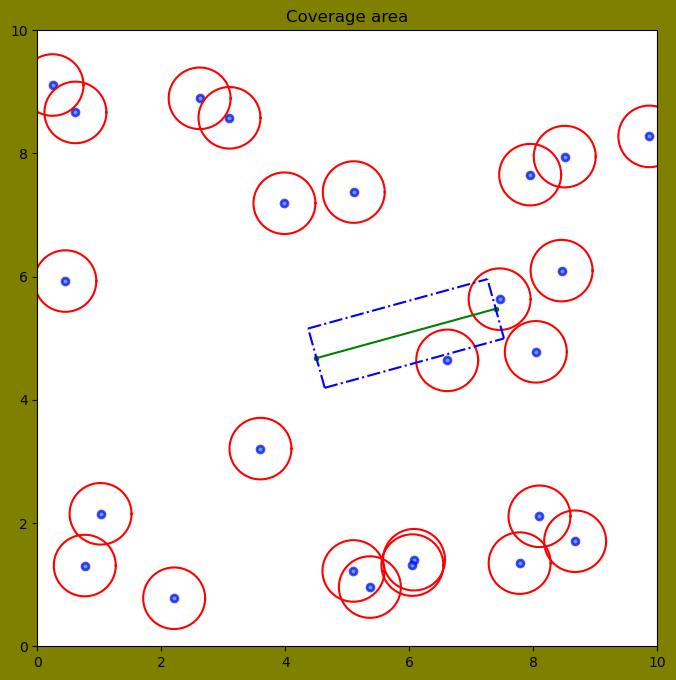

In [10]:
x, y = poisson_point_process(poisson_lam_block, guard_size)
x1 = np.random.uniform (0, guard_size) 
y1 = np.random.uniform (0, guard_size) 
angle = np.random.uniform (0,2 * np.pi) 
x2 = x1 + distance_Tx_Rx * np.cos(angle) 
y2= y1 + distance_Tx_Rx * np.sin(angle)
x_rectang_A, y_rectang_A, x_rectang_B, y_rectang_B, x_rectang_C, y_rectang_C, x_rectang_D, y_rectang_D = paint_rectangle(x1, y1, x2, y2, angle)

plt.figure(dpi=100, figsize=(8,8),facecolor='olive')
plt.title('Coverage area')
plt.plot(x,y,'.',alpha=0.7, label="first", lw=5, mec='b', mew=2, ms=10)
for i in range(len(x)):
    plot_circle(x[i], y[i], radius_block)
plt.plot([x1,x2], [y1,y2], '.-g')

plt.plot([x_rectang_A,x_rectang_B], [y_rectang_A,y_rectang_B], '-.b')
plt.plot([x_rectang_A,x_rectang_D], [y_rectang_A,y_rectang_D], '-.b')
plt.plot([x_rectang_B,x_rectang_C], [y_rectang_B,y_rectang_C], '-.b')
plt.plot([x_rectang_D,x_rectang_C], [y_rectang_D,y_rectang_C], '-.b')
plt.xlim(0, guard_size) 
plt.ylim(0, guard_size)
plt. show()

In [64]:
if (crossing()):
    print('Los blocked')
else:
    print ('LoS is not blocked')

Los blocked


<h2> Задание 3 </h2>

На основе описанного выше алгоритма получили 1000 реализаций
факта блокировки линии прямой видимости и рассчитать
вероятность блокировки линии прямой видимости в поле
блокирующих объектов. Полученный результат сравнили с
результатами математической модели


In [11]:
#Имитационное моделирование
N = 1000
summa = 0

for i in range(N):
    x, y = poisson_point_process(poisson_lam_block,guard_size)
    x1 = np.random.uniform (0, guard_size)
    y1 = np.random.uniform (0, guard_size)
    angle = np.random.uniform (0,2 * np.pi)
    x2 = x1 + distance_Tx_Rx * np.cos(angle)
    y2 = y1 + distance_Tx_Rx * np.sin(angle)
    if (crossing()):
        summa += 1
print("Вероятность блокировки: ", summa/N)


Вероятность блокировки:  0.613


In [12]:
# Вероятность блокировки по аналитической формуле
s = 2 * radius_block * distance_Tx_Rx 
lamb = poisson_lam_block * s
probability = 1 - np.exp(-lamb)
print("Вероятность блокировки по аналитической формуле:", probability)

Вероятность блокировки по аналитической формуле: 0.5934303402594008


<h2> Вывод </h2>

В ходе выполнения лабораторной работы были изучены модели размещения пользователей и распространения сигнала